# Module End Assignment: 
# Python For Data Analysis

#     “Social Media Engagement Analytics”

In [1]:
# Task 1 — Data Import & Setup

In [4]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("social_media_engagement_5000.csv")

# Display first 5 rows
display(df.head())

# Check dataset information
df.info()

# Check shape
print("Dataset Shape:", df.shape)

# Check column names
print("Column Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   str    
 3   country           5000 non-null   str    
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   str    
 6   post_category     5000 non-null   str    
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   str    
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   str    
 16  sentiment         4850 non-null   str    
 17  hashta

In [8]:
# Task 2 — Data Cleaning: Missing Data

In [9]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Separate numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

# Fill numerical missing values with median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_6592\2071561252.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns



Missing values after cleaning:
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [11]:
# Data Formatting

In [14]:
print(df.columns.tolist())

['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']


In [15]:
# 1 Fix Incorrect Data Types

In [16]:
df.dtypes

user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object

In [18]:
date_columns = [col for col in df.columns if "date" in col.lower()]

print("Date columns found:", date_columns)

Date columns found: []


In [19]:
# Duplicate Handling- Identify & remove duplicates

In [20]:
# Identify duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Display duplicate rows
df[df.duplicated()]

Number of duplicate rows: 0


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate


In [21]:
# Remove duplicates
df = df.drop_duplicates()

# Verify
print("Number of duplicate rows after removal:", df.duplicated().sum())
print("Updated dataset shape:", df.shape)

Number of duplicate rows after removal: 0
Updated dataset shape: (5000, 19)


In [22]:
#Data Formatting

# 1. Fix incorrect data types

In [23]:
print(df.dtypes)

user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object


In [24]:
df["likes"] = pd.to_numeric(df["likes"], errors="coerce")
df["comments"] = pd.to_numeric(df["comments"], errors="coerce")
df["shares"] = pd.to_numeric(df["shares"], errors="coerce")

In [25]:
# Standardize categories
df["gender"].unique()

<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [27]:
df["gender"] = df["gender"].astype(str).str.strip().str.lower()

df["gender"] = df["gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
})
print(df["gender"].unique())

<ArrowStringArray>
['Female', 'Male', 'other']
Length: 3, dtype: str


In [28]:
# Feature Cleaning

In [29]:
# 1. Extract Hashtag Count

In [32]:
print(df.columns.tolist())

['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']


In [33]:
print(df["hashtags"].head())

0    #foodie #travel #love
1                 #fitness
2                  #foodie
3      #music #foodie #fun
4                  #travel
Name: hashtags, dtype: str


In [34]:
import re

df["hashtag_count"] = df["hashtags"].apply(
    lambda x: len(re.findall(r"#\w+", str(x)))
)

df[["hashtags", "hashtag_count"]].head()

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


In [35]:
# 2. Clean Sentiment Labels

In [36]:
print(df["sentiment"].unique())

<ArrowStringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str


In [39]:
# Task 3 — Data Exploration using Pandas

In [41]:
# View dataset structure

In [42]:
# First 5 rows:
df.head()

# Last 5 rows:
df.tail()

#Number of rows and columns:
df.shape

# Column names:
df.columns

# 2. Check data types and information
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               5000 non-null   float64
 2   gender            5000 non-null   str    
 3   country           5000 non-null   str    
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   str    
 6   post_category     5000 non-null   str    
 7   likes             5000 non-null   float64
 8   comments          5000 non-null   float64
 9   shares            5000 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   str    
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   str    
 16  sentiment         5000 non-null   str    
 17  hashta

In [43]:
df.dtypes

user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
hashtag_count         int64
dtype: object

In [44]:
# 3. Generate summary statistics
# For numeric columns:
df.describe()

# For both numeric and categorical columns:
df.describe(include="all")


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000,5000,5000.000000,5000,5000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000,5000,5000,5000,5000.000000,5000.000000
unique,NaN,NaN,3,10,NaN,4,8,NaN,NaN,NaN,NaN,NaN,729,NaN,2,3,3,761,NaN,NaN
top,NaN,NaN,Male,India,NaN,reel,fitness,NaN,NaN,NaN,NaN,NaN,26-12-2023,NaN,False,mobile,Positive,#tech,NaN,NaN
freq,NaN,NaN,1849,535,NaN,1283,675,NaN,NaN,NaN,NaN,NaN,16,NaN,4517,1684,2513,201,NaN,NaN
mean,54561.890800,38.440400,NaN,NaN,548042.909000,NaN,NaN,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,NaN,393698.224800,NaN,NaN,NaN,NaN,0.964356,1.998600
std,26090.370121,14.687151,NaN,NaN,260646.957267,NaN,NaN,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,NaN,NaN,NaN,NaN,5.318029,0.812853
min,10055.000000,13.000000,NaN,NaN,100068.000000,NaN,NaN,10.000000,0.000000,0.0000,0.000000,105.000000,NaN,87.000000,NaN,NaN,NaN,NaN,0.006363,1.000000
25%,32309.500000,26.000000,NaN,NaN,322543.500000,NaN,NaN,5235.000000,792.000000,511.0000,2017.750000,24988.250000,NaN,194480.000000,NaN,NaN,NaN,NaN,0.145781,1.000000
50%,54374.500000,38.000000,NaN,NaN,548077.500000,NaN,NaN,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,NaN,388982.000000,NaN,NaN,NaN,NaN,0.253896,2.000000
75%,77180.500000,51.000000,NaN,NaN,771574.500000,NaN,NaN,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,NaN,589744.250000,NaN,NaN,NaN,NaN,0.504794,3.000000


In [46]:
# 4. Analyze categorical distributions
# Check unique values
df["post_type"].unique()

# Count unique values
df["post_type"].nunique()

# Frequency distribution
df["post_type"].value_counts()

df["sentiment"].value_counts()

#And country:
df["country"].value_counts()

country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

In [47]:
# 5. Create a correlation matrix

# Select the numeric columns:
numeric_df = df.select_dtypes(include="number")

# Create the correlation matrix:
correlation_matrix = numeric_df.corr()

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


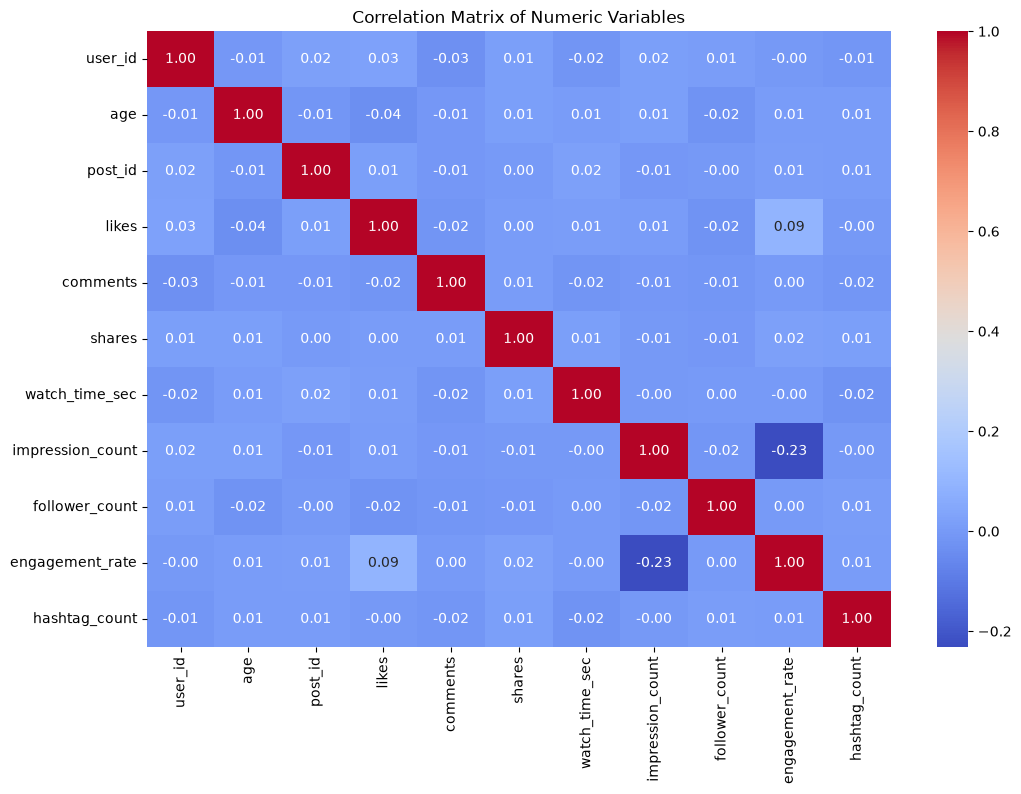

In [48]:
# For a visual correlation matrix, use Seaborn:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numeric Variables")
plt.show()

In [49]:
# 6. Use groupby() for analysis

# Average likes by post type
df.groupby("post_type")["likes"].mean()

# For a cleaner output:
avg_likes_by_post_type = (
    df.groupby("post_type")["likes"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_likes_by_post_type)

# Average comments by post type
df.groupby("post_type")["comments"].mean()

# Average shares by post type
df.groupby("post_type")["shares"].mean()

# Average impressions by post category
df.groupby("post_category")["impression_count"].mean()

# Average engagement rate by post type
df.groupby("post_type")["engagement_rate"].mean()



post_type
video    10188.600000
image    10104.865277
text     10100.148193
reel     10037.802416
Name: likes, dtype: float64


post_type
image    0.895646
reel     0.783047
text     1.064549
video    1.122365
Name: engagement_rate, dtype: float64

In [50]:
# 7. Multiple metrics using groupby()

df.groupby("post_type").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "mean",
    "engagement_rate": "mean"
})

,likes,comments,shares,impression_count,engagement_rate
post_type,,,,,
image,10104.865277,1525.235766,1019.289495,49727.421812,0.895646
reel,10037.802416,1504.187062,982.042089,50462.598597,0.783047
text,10100.148193,1499.106024,1013.989558,49987.218474,1.064549
video,10188.600000,1479.160000,996.834286,49862.014694,1.122365


In [51]:
# Task 4 — Data Wrangling

In [52]:
import numpy as np
import re

# 1. Create engagement score
df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)

# 2. Optional log transformations
df["log_likes"] = np.log1p(df["likes"])
df["log_comments"] = np.log1p(df["comments"])
df["log_shares"] = np.log1p(df["shares"])
df["log_impressions"] = np.log1p(df["impression_count"])

# 3. Hashtag count
df["hashtag_count"] = df["hashtags"].apply(
    lambda x: len(re.findall(r"#\w+", str(x)))
)

# 4. Groupby Post Type
post_type_summary = df.groupby("post_type").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "mean",
    "engagement_score": "mean",
    "engagement_rate": "mean"
}).round(2)

print("Summary by Post Type:")
display(post_type_summary)

# 5. Groupby Country
country_summary = df.groupby("country").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "mean",
    "engagement_score": "mean",
    "engagement_rate": "mean"
}).round(2)

print("Summary by Country:")
display(country_summary)

# 6. Groupby Sentiment
sentiment_summary = df.groupby("sentiment").agg({
    "likes": "mean",
    "comments": "mean",
    "shares": "mean",
    "impression_count": "mean",
    "engagement_score": "mean",
    "engagement_rate": "mean"
}).round(2)

print("Summary by Sentiment:")
display(sentiment_summary)

Summary by Post Type:


,likes,comments,shares,impression_count,engagement_score,engagement_rate
post_type,,,,,,
image,10104.87,1525.24,1019.29,49727.42,12649.39,0.90
reel,10037.80,1504.19,982.04,50462.60,12524.03,0.78
text,10100.15,1499.11,1013.99,49987.22,12613.24,1.06
video,10188.60,1479.16,996.83,49862.01,12664.59,1.12


Summary by Country:


,likes,comments,shares,impression_count,engagement_score,engagement_rate
country,,,,,,
Australia,10294.12,1485.80,1029.69,48346.38,12809.62,1.32
Brazil,9886.69,1490.43,1008.86,49193.17,12385.98,1.54
Canada,10063.07,1546.58,996.25,48703.15,12605.89,0.92
France,10372.88,1478.70,1051.81,51727.67,12903.38,1.15
Germany,10130.46,1531.83,973.38,48605.41,12635.66,0.76
India,9962.47,1494.92,1035.32,52462.39,12492.70,0.66
Japan,10088.86,1530.43,959.35,49616.14,12578.65,0.77
UAE,10227.49,1541.21,989.08,48928.41,12757.78,1.11
UK,9935.65,1463.04,985.68,51119.39,12384.37,0.85


Summary by Sentiment:


,likes,comments,shares,impression_count,engagement_score,engagement_rate
sentiment,,,,,,
Negative,10208.10,1516.09,1007.31,50191.96,12731.50,1.04
Neutral,9923.19,1528.40,996.57,49515.97,12448.16,0.99
Positive,10180.06,1480.65,1005.09,50248.11,12665.80,0.92


In [53]:
#  Task 5 — Statistical Analysis

In [54]:
import pandas as pd

# Columns for statistical analysis
stats_columns = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

stats_df = df[stats_columns]

# Descriptive statistics
descriptive_stats = pd.DataFrame({
    "Mean": stats_df.mean(),
    "Median": stats_df.median(),
    "Mode": stats_df.mode().iloc[0],
    "Standard Deviation": stats_df.std(),
    "Variance": stats_df.var(),
    "Skewness": stats_df.skew(),
    "Kurtosis": stats_df.kurtosis()
})

print("Descriptive Statistics:")
display(descriptive_stats.round(2))

# Percentiles
percentiles = stats_df.quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95]
)

print("Percentiles:")
display(percentiles.round(2))

Descriptive Statistics:


,Mean,Median,Mode,Standard Deviation,Variance,Skewness,Kurtosis
likes,10107.00,10105.50,10105.50,5702.29,3.251615e+07,-0.01,-1.15
comments,1502.04,1497.00,1497.00,856.39,7.334095e+05,0.00,-1.14
shares,1002.91,1012.00,1012.00,570.86,3.258757e+05,-0.01,-1.15
watch_time_sec,4014.50,4034.50,916.00,2308.10,5.327309e+06,-0.02,-1.20
engagement_rate,0.96,0.25,0.01,5.32,2.828000e+01,18.78,482.99
follower_count,393698.22,388982.00,497502.00,230927.88,5.332769e+10,0.04,-1.19


Percentiles:


,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.00,792.00,511.00,2017.75,0.15,194480.00
0.50,10105.50,1497.00,1012.00,4034.50,0.25,388982.00
0.75,14959.00,2235.25,1483.00,6020.25,0.50,589744.25
0.90,18016.30,2695.10,1795.10,7212.10,1.20,717755.90
0.95,19097.05,2861.00,1901.05,7577.05,2.33,760174.35


In [56]:
# Task 6 — Data Visualization (Min. 8 Plots Required)

In [57]:
# Matplotlib

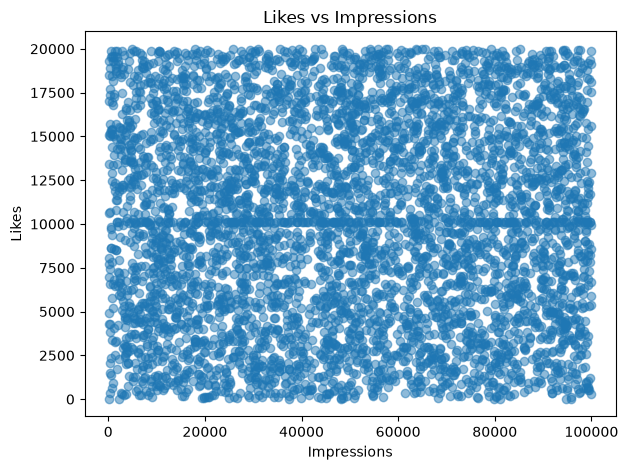

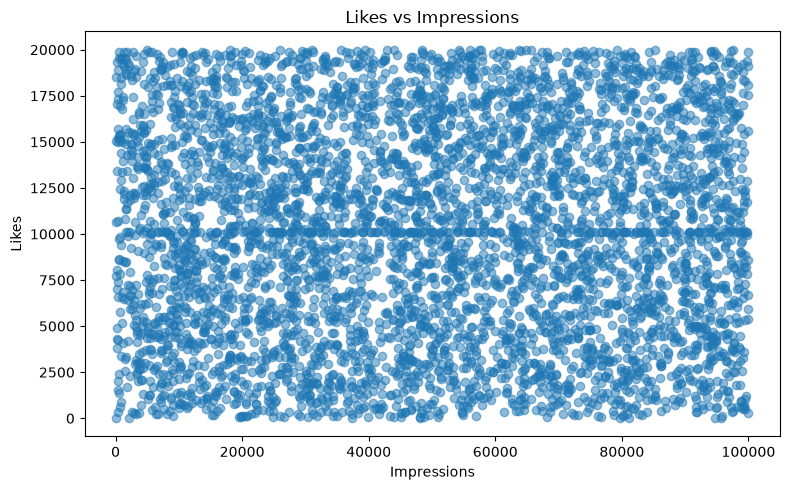

In [58]:
# Scatter: likes vs impressionsplt.figure(figsize=(8, 5))

plt.scatter(df["impression_count"], df["likes"], alpha=0.5)

plt.title("Likes vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Likes")

plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))

plt.scatter(df["impression_count"], df["likes"], alpha=0.5)

plt.title("Likes vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Likes")

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_6592\4000065927.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["posted_at"] = pd.to_datetime(df["posted_at"], errors="coerce")


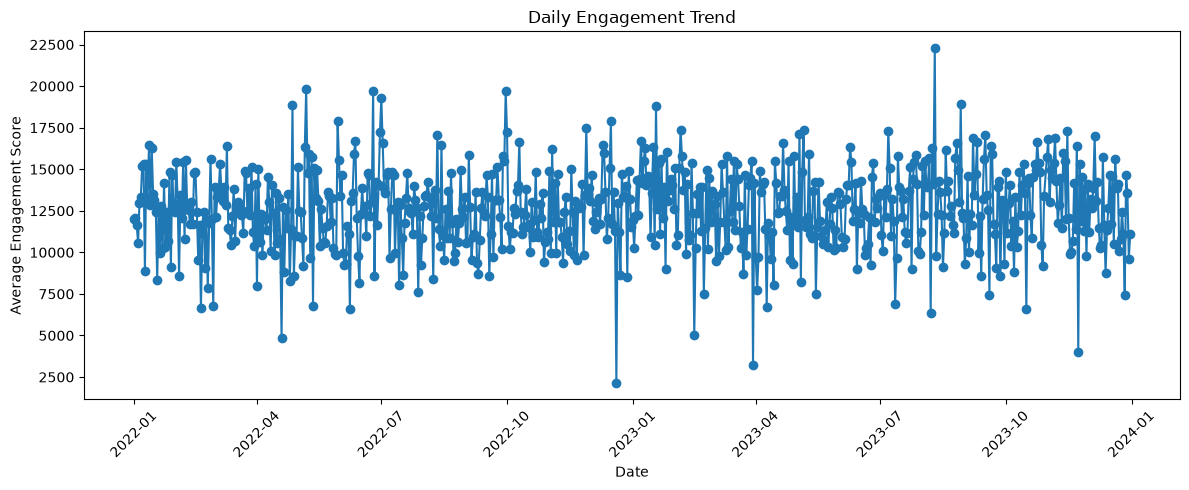

In [59]:
# Line: daily engagement trend

df["posted_at"] = pd.to_datetime(df["posted_at"], errors="coerce")

daily_engagement = (
    df.groupby(df["posted_at"].dt.date)["engagement_score"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_engagement.index,
    daily_engagement.values,
    marker="o"
)

plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Average Engagement Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

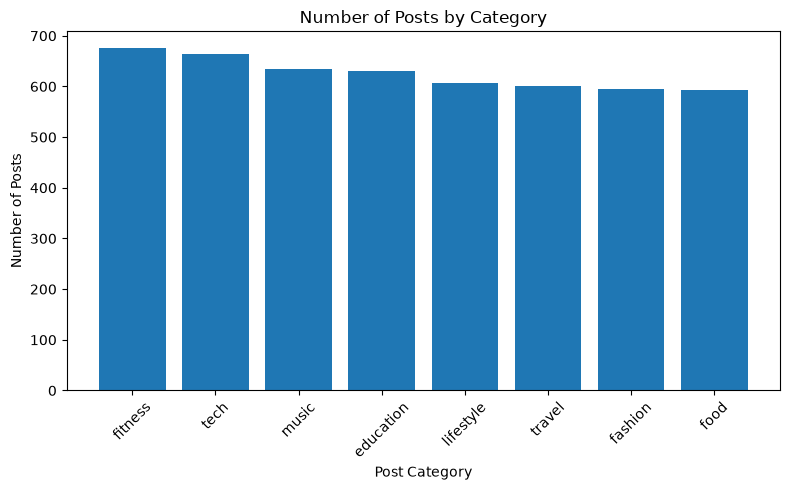

In [60]:
# Bar: posts by category

category_counts = df["post_category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Number of Posts by Category")
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

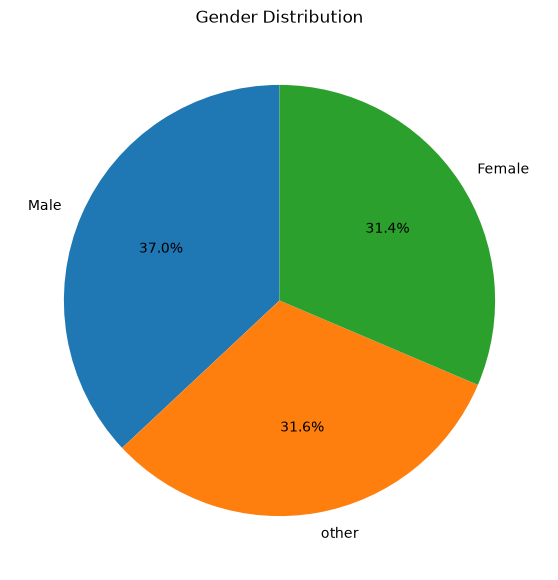

In [61]:
# Pie: gender distribution

gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.show()

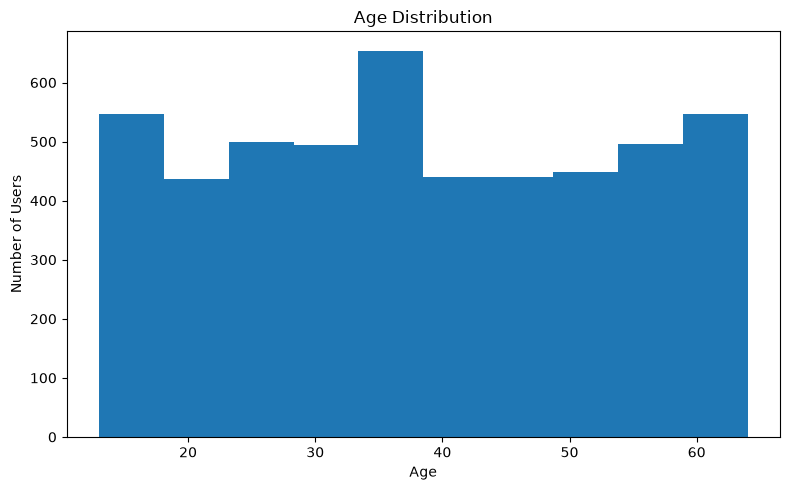

In [63]:
# Histogram — Age Distribution


plt.figure(figsize=(8, 5))

plt.hist(
    df["age"].dropna(),
    bins=10
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()


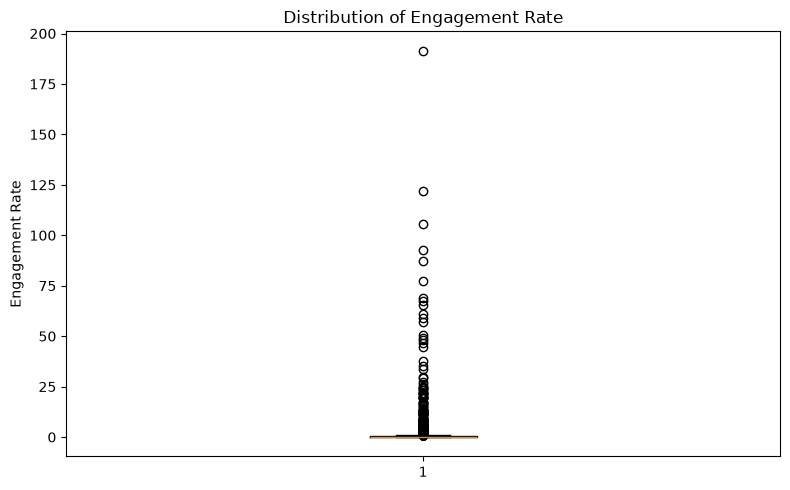

In [64]:
# Box Plot — Engagement Rate

plt.figure(figsize=(8, 5))

plt.boxplot(
    df["engagement_rate"].dropna()
)

plt.title("Distribution of Engagement Rate")
plt.ylabel("Engagement Rate")

plt.tight_layout()
plt.show()

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

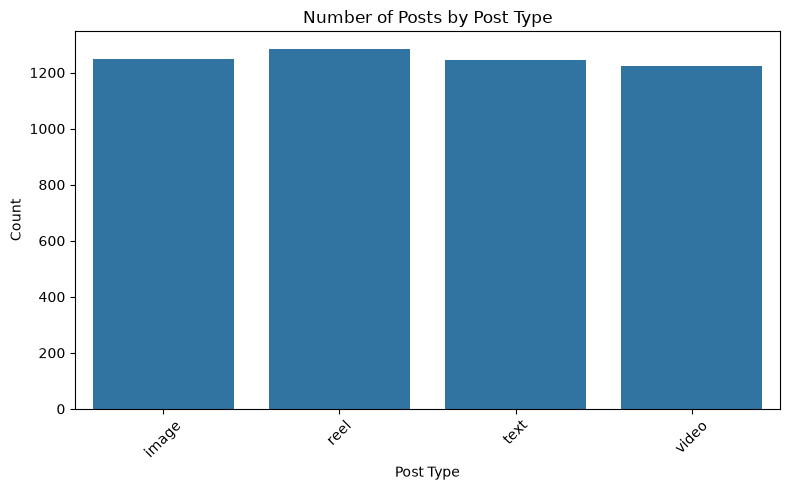

In [66]:
# Count Plot — Post Type

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="post_type")

plt.title("Number of Posts by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

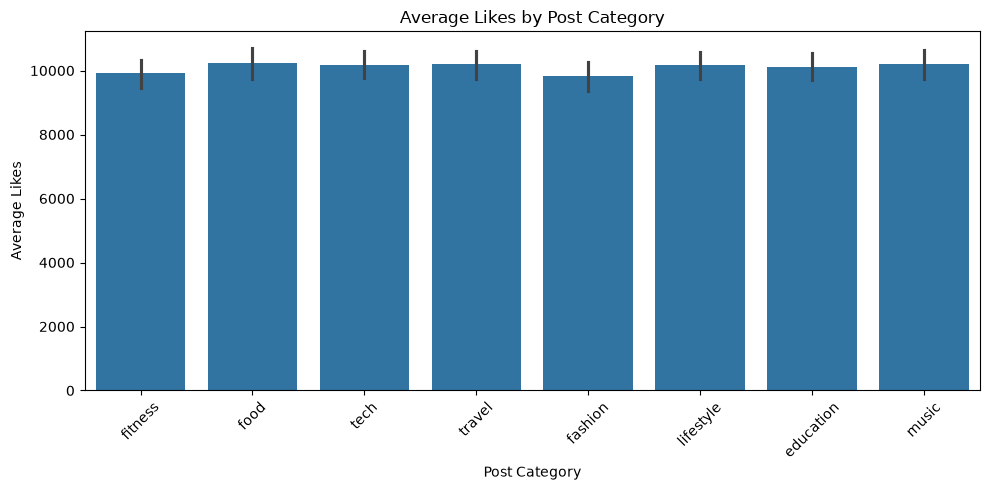

In [68]:
#Bar Plot — Average Likes by Category

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="post_category",
    y="likes",
    estimator="mean"
)

plt.title("Average Likes by Post Category")
plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

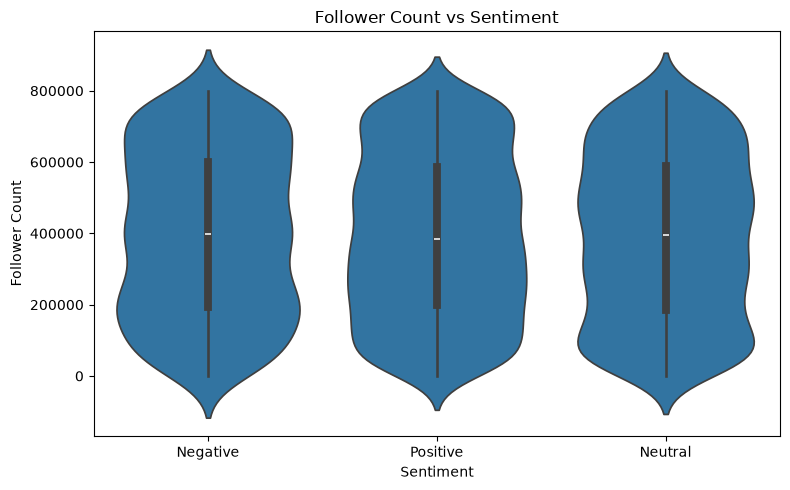

In [69]:
# Violin Plot — Followers vs Sentiment

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)

plt.title("Follower Count vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")

plt.tight_layout()
plt.show()

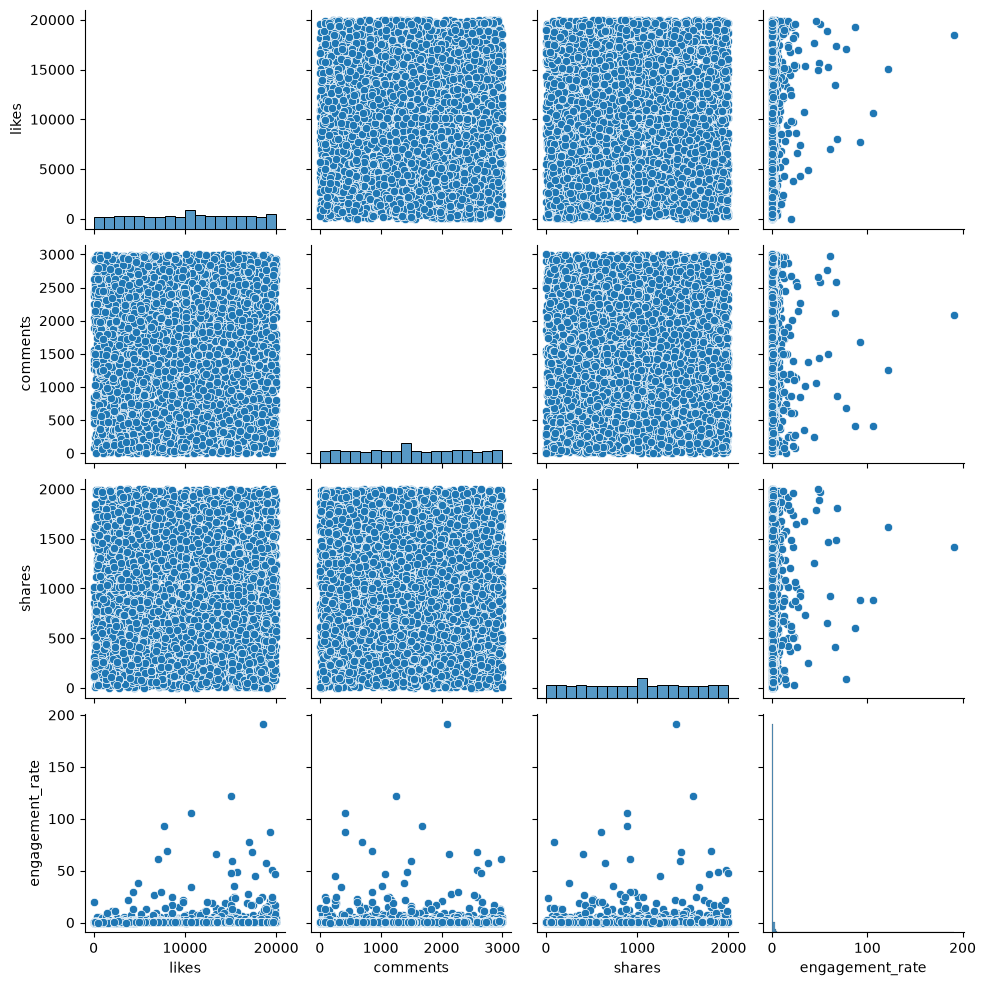

In [70]:
# Pair Plot — Numeric Features

numeric_features = [
    "likes",
    "comments",
    "shares",
    "engagement_rate"
]

sns.pairplot(
    df[numeric_features].dropna()
)

plt.show()

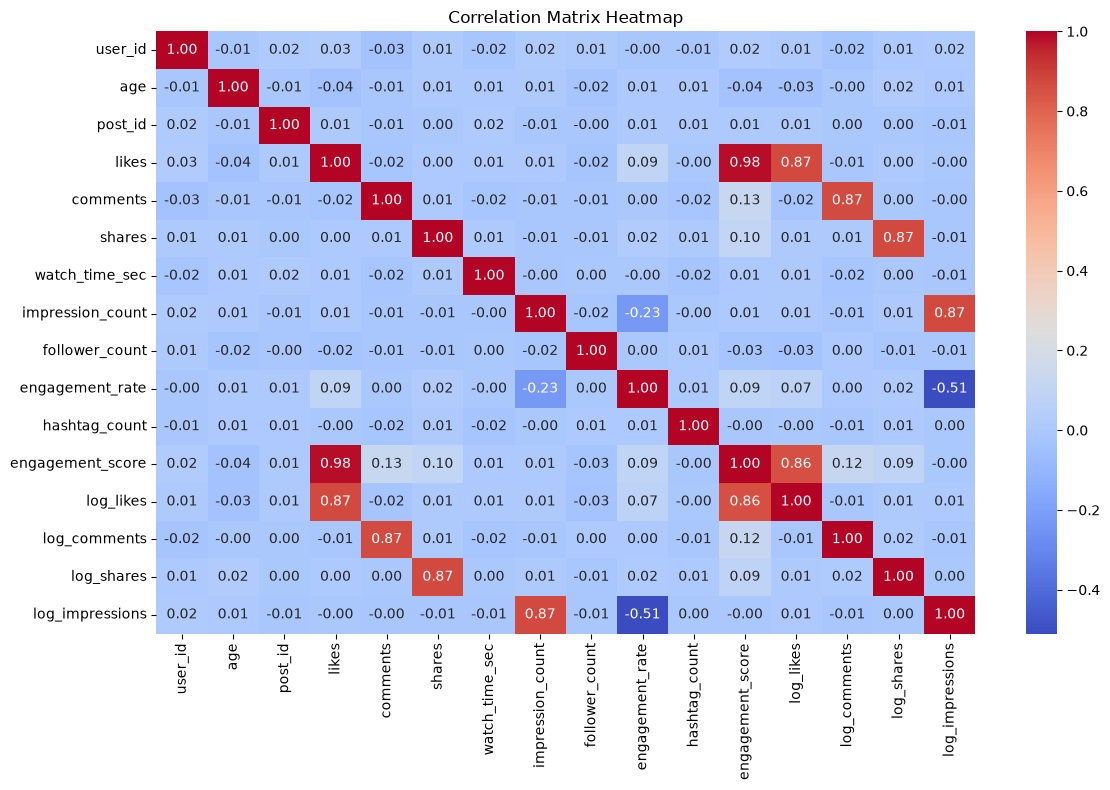

In [71]:
# Heatmap: correlation matrix

# First create the correlation matrix:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

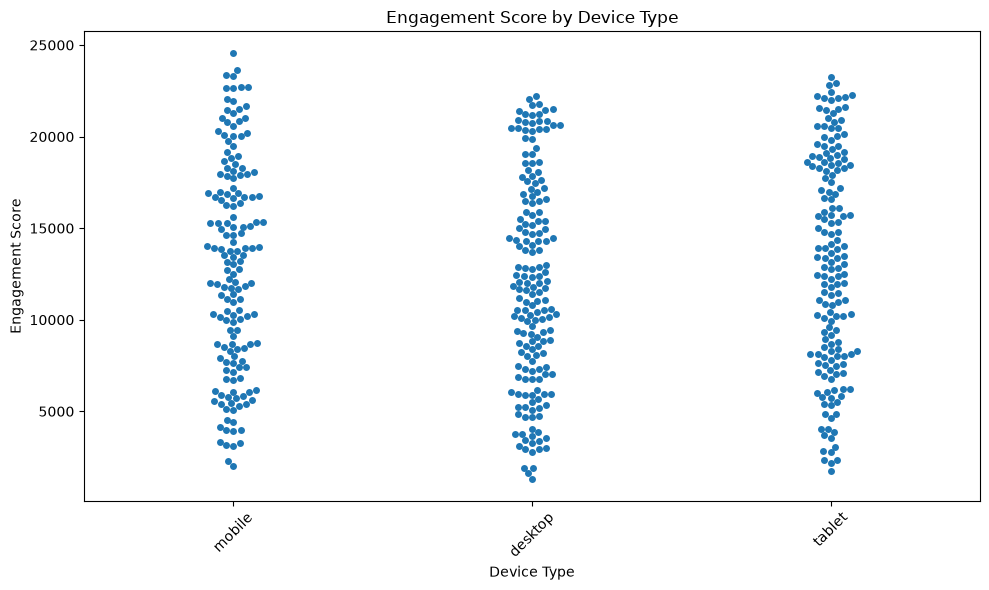

In [72]:
# Swarm Plot — Engagement vs Device
# dataset has device_type and engagement_score, so use those:

sample_df = df.sample(
    n=min(500, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.swarmplot(
    data=sample_df,
    x="device_type",
    y="engagement_score"
)

plt.title("Engagement Score by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Engagement Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [73]:
# Plotly – Interactive Scatter Chart

import plotly.express as px

fig = px.scatter(
    df,
    x="impression_count",
    y="likes",
    color="post_type",
    size="engagement_score",
    hover_data=["sentiment", "country", "device_type"],
    title="Interactive Scatter Chart: Impressions vs Likes"
)

fig.update_layout(
    xaxis_title="Impression Count",
    yaxis_title="Likes",
    legend_title="Post Type"
)

fig.show()

In [5]:
print(df.columns.tolist())

['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']


# ❖ Final Insights should include the following analysis:

In [15]:
# Content Performance: 

In [9]:
# 1. Which post types have the highest engagement?

# Since your dataset has no total engagement column, we can calculate engagement as:

#Likes + Comments + Shares

df["engagement"] = df["likes"] + df["comments"] + df["shares"]

post_type_engagement = (
    df.groupby("post_type")["engagement"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Engagement by Post Type:")
print(post_type_engagement)

Average Engagement by Post Type:
post_type
video    12658.675844
image    12627.062882
reel     12560.733850
text     12529.878199
Name: engagement, dtype: float64


In [10]:
print("\nHighest Engagement Post Type:")
print(post_type_engagement.idxmax())


Highest Engagement Post Type:
video


In [11]:
# 2. Best-performing Content Category

# column has  post_category, not category.

category_engagement = (
    df.groupby("post_category")["engagement"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Engagement by Content Category:")
print(category_engagement)

Average Engagement by Content Category:
post_category
music        12896.741710
food         12656.661710
tech         12649.633117
lifestyle    12616.940109
travel       12595.420857
education    12594.467826
fitness      12483.886614
fashion      12249.938889
Name: engagement, dtype: float64


In [12]:
print("\nBest-Performing Content Category:")
print(category_engagement.idxmax())


Best-Performing Content Category:
music


In [13]:
# 3 Which countries have the highest average engagement rate?

# dataset already has an engagement_rate column, so we can use it directly.

country_engagement = (
    df.groupby("country")["engagement_rate"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Engagement Rate by Country:")
print(country_engagement)

Average Engagement Rate by Country:
country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64


In [14]:
print("\nTop 10 Countries by Average Engagement Rate:")
print(country_engagement.head(10))


Top 10 Countries by Average Engagement Rate:
country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64


In [16]:
# User Trends

In [17]:
# 1. How Age Affects Engagement

# A scatter plot is useful here because age is numeric and engagement is numeric.

# First calculate average engagement by age:

age_engagement = (
    df.groupby("age")["engagement"]
      .mean()
      .sort_index()
)

print("Average Engagement by Age:")
print(age_engagement)

Average Engagement by Age:
age
13.0    12680.452055
14.0    13228.698925
15.0    12900.486486
16.0    12330.134146
17.0    14053.046512
18.0    12477.159091
19.0    11839.535714
20.0    13233.418919
21.0    12564.265823
22.0    12207.925000
23.0    12480.202703
24.0    13220.806122
25.0    13144.270000
26.0    11914.012500
27.0    12453.470588
28.0    11960.357143
29.0    13087.306122
30.0    12892.000000
31.0    12664.168831
32.0    13090.390805
33.0    13874.568182
34.0    12805.974359
35.0    12369.901961
36.0    13458.829787
37.0    11932.045455
38.0    13334.314815
39.0    13487.900000
40.0    11637.955556
41.0    12039.780220
42.0    12358.383562
43.0    12566.987500
44.0    12515.756410
45.0    12719.130952
46.0    12264.898734
47.0    11693.891566
48.0    12653.333333
49.0    14486.547619
50.0    13196.387500
51.0    12208.828283
52.0    12433.551282
53.0    11341.507246
54.0    12110.096154
55.0    11502.551724
56.0    12779.714286
57.0    12283.626374
58.0    11594.291139
59.

In [18]:
age_correlation = df["age"].corr(df["engagement"])

print("Correlation between Age and Engagement:")
print(age_correlation)

Correlation between Age and Engagement:
-0.03761822515508393


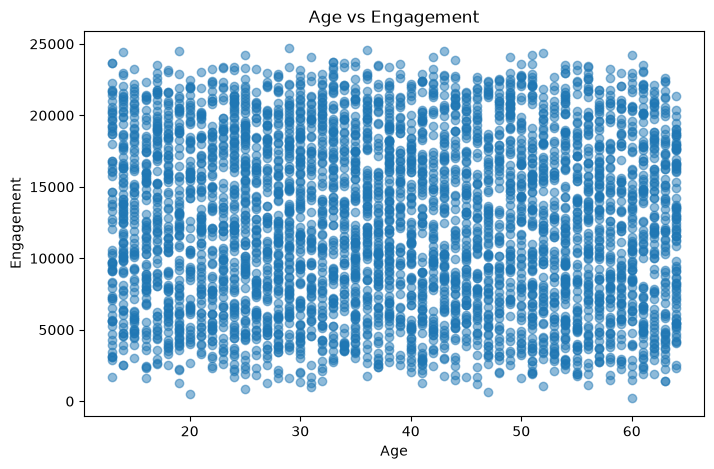

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["age"], df["engagement"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Engagement")
plt.title("Age vs Engagement")
plt.show()

In [20]:
# 2. Performance Difference for Verified Accounts

# the account is verified

verified_performance = (
    df.groupby("is_verified")[["engagement", "engagement_rate"]]
      .mean()
)

print("Performance by Verification Status:")
print(verified_performance)

Performance by Verification Status:
               engagement  engagement_rate
is_verified                               
False        12617.413223         0.954744
True         12379.117517         1.054250


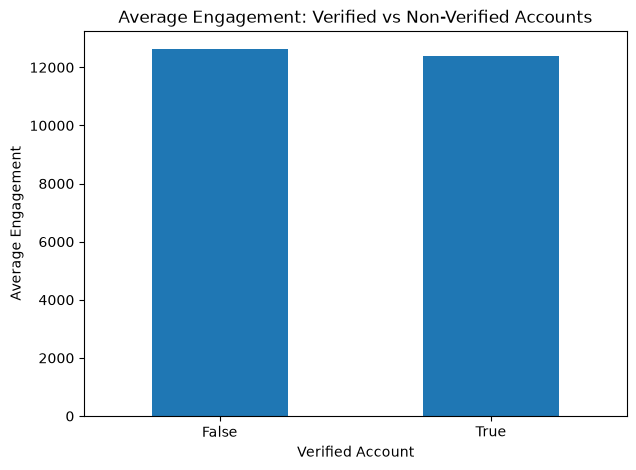

In [21]:
import matplotlib.pyplot as plt

verified_performance["engagement"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Verified Account")
plt.ylabel("Average Engagement")
plt.title("Average Engagement: Verified vs Non-Verified Accounts")
plt.xticks(rotation=0)
plt.show()

In [22]:
# Behavioral Insights 

In [24]:
# First, create a time-of-day column from posted_at.

# Convert posted_at to datetime
df["posted_at"] = pd.to_datetime(df["posted_at"])

# Extract hour
df["hour"] = df["posted_at"].dt.hour

# Calculate average impressions by hour
hourly_impressions = (
    df.groupby("hour")["impression_count"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Impressions by Hour:")
print(hourly_impressions)

C:\Users\User\AppData\Local\Temp\ipykernel_11988\3063220169.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["posted_at"] = pd.to_datetime(df["posted_at"])


Average Impressions by Hour:
hour
0    50013.7328
Name: impression_count, dtype: float64


In [25]:
# To identify the hour with the highest average impressions:

best_hour = hourly_impressions.idxmax()
best_impressions = hourly_impressions.max()

print("Best Time of Day for Impressions:")
print(f"{best_hour}:00")
print(f"Average Impressions: {best_impressions:.2f}")

Best Time of Day for Impressions:
0:00
Average Impressions: 50013.73


In [26]:
# 2. Device Type Impact on Watch Time

# compare watch_time_sec across different devices.

device_watch_time = (
    df.groupby("device_type")["watch_time_sec"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Watch Time by Device Type:")
print(device_watch_time)

Average Watch Time by Device Type:
device_type
mobile     4087.830760
tablet     3979.736429
desktop    3974.792521
Name: watch_time_sec, dtype: float64


In [27]:
# Find the device with the highest average watch time:

In [28]:
best_device = device_watch_time.idxmax()
best_watch_time = device_watch_time.max()

print("\nDevice with Highest Average Watch Time:")
print(best_device)
print(f"Average Watch Time: {best_watch_time:.2f} seconds")


Device with Highest Average Watch Time:
mobile
Average Watch Time: 4087.83 seconds


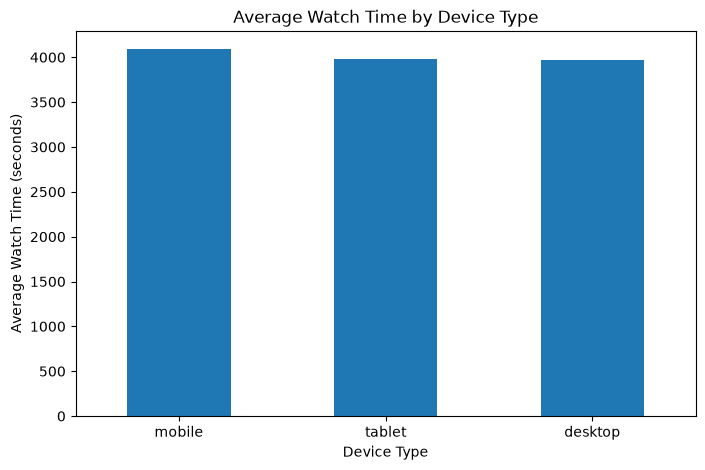

In [29]:
# Visualization

# A bar chart will make the device comparison clear:

import matplotlib.pyplot as plt

device_watch_time.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Device Type")
plt.ylabel("Average Watch Time (seconds)")
plt.title("Average Watch Time by Device Type")
plt.xticks(rotation=0)
plt.show()

In [31]:
# Sentiment Analysis

In [32]:
# 1. Which Sentiment Performs Best

# Since we already created the engagement column:

sentiment_performance = (
    df.groupby("sentiment")[["engagement", "engagement_rate", "impression_count"]]
      .mean()
      .sort_values("engagement", ascending=False)
)

print("Sentiment Performance:")
print(sentiment_performance)

# To identify the sentiment with the highest average engagement:

best_sentiment = sentiment_performance["engagement"].idxmax()
best_engagement = sentiment_performance["engagement"].max()

print("\nBest-Performing Sentiment:")
print(best_sentiment)
print(f"Average Engagement: {best_engagement:.2f}")

Sentiment Performance:
             engagement  engagement_rate  impression_count
sentiment                                                 
negative   12745.962670         1.038486      50191.960417
positive   12593.029963         0.954800      49986.155734
neutral    12459.355160         0.991170      49515.971185

Best-Performing Sentiment:
negative
Average Engagement: 12745.96


In [33]:
# 2. Behavior of Negative and Neutral Sentiment Posts

# Let's specifically compare Negative and Neutral posts.

negative_neutral = (
    df[df["sentiment"].isin(["Negative", "Neutral"])]
    .groupby("sentiment")[["engagement", "engagement_rate", "impression_count", "likes", "comments", "shares"]]
    .mean()
)

print("Negative vs Neutral Posts:")
print(negative_neutral)

Negative vs Neutral Posts:
Empty DataFrame
Columns: [engagement, engagement_rate, impression_count, likes, comments, shares]
Index: []


In [34]:
print("Number of Negative and Neutral Posts:")
print(
    df[df["sentiment"].isin(["Negative", "Neutral"])]["sentiment"]
      .value_counts()
)

Number of Negative and Neutral Posts:
Series([], Name: count, dtype: int64)


# Assignment MODULE 5 "Social Media Engagement Analytics" has been completed*

# Thank you !!!